# Notebook 5 — Which strategies matter?

*SWC ENC 2026 · behaviour module*

The AUC in Notebook 4 told us *how well* the model predicts, but not *which of
the five strategies* is doing the work. To find out, we **ablate**: remove a
strategy, refit, and see how much the model's predictions suffer. The strategies
whose removal hurts most are the ones the mouse is really using.

We'll measure "how much it hurts" with the **held-out log-likelihood** you
already built in Notebook 4 — a fair, overfitting-resistant currency. (The paper
uses a more elaborate quantity, *model evidence*; that's the optional advanced
section at the end, for anyone who wants the full picture.)

**In this notebook you will:**
1. Score a model by its cross-validated **log-likelihood**.
2. **Ablate** each strategy and read off how much it contributes.
3. Turn those contributions into the paper's **strategy index** (Fig 2D–F).
4. *(Optional, advanced)* Redo the ablation with **model evidence**.

---
**The paper panels this notebook reproduces**

<img src="../assets/paper/fig2b.png" width="300">

*Fig. 2B — the fitted strategy weights, averaged across sessions.*

<img src="../assets/paper/fig2d.png" width="320">

*Fig. 2D — how much the model's evidence drops when each strategy is removed
(ablation). This notebook builds that ablation and the strategy indices it feeds.*

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import swcbehav as sb

def get_Xy(sess):
    # Observable design matrix, per-image outcome, and column names.
    X, cols = sb.build_design_matrix(sess.table)
    y = sess.table["bout_start"].to_numpy().astype(float)
    return X, y, cols

## 1. Scoring a model by the probability it assigns

We need a way to rank models by how well they predict licking. A natural score
comes straight from the likelihood we built in Notebook 3. On a single image the
model assigns probability $p_t$ to a bout and $1-p_t$ to no bout, so the
probability it placed on **what actually happened** is

$$\text{(prob of the observed outcome)} =
  \begin{cases} p_t & \text{if a bout started} \\ 1 - p_t & \text{if not.} \end{cases}$$

A good model puts high probability on what really happened. Take the log of that
number on each image and average over images, and you get the **log-likelihood per
image** — our score. It is always negative (the log of a probability below 1), and
*higher* (closer to zero) means the model was, on average, **less surprised** by
the data. Crucially we compute it on **held-out** images — using the
cross-validation from Notebook 4 — so a model can't score well just by memorizing
the images it was fit on.

> **A note on units.** Because we took the *natural* log, the score comes out in
> units called **nats**; with $\log_2$ it would be in bits. The unit is
> immaterial here — we only ever compare these numbers to one another. A gap of,
> say, $0.1$ nats/image means one model assigned about $e^{0.1}\approx 1.1\times$
> more probability, per image, to the held-out licking than the other.

**Why not just reuse the AUC?** The AUC from Notebook 4 only asks whether bouts are
*ranked* above quiet images; it ignores the actual probability values. The
log-likelihood cares about those values, so it rewards a model whose probabilities
are **calibrated** — when it says "30% chance of a bout," a bout really does happen
about 30% of the time. A model that orders images well but is over-confident
(saying 99% when the truth is 60%) earns a fine AUC but a poor log-likelihood.
That sensitivity to the actual probabilities is exactly what we want when asking
whether *adding a strategy* genuinely buys the model anything.

In [2]:
sess = sb.make_mouse("visual", seed=0)
X, y, cols = get_Xy(sess)
full_ll = sb.cross_val_loglik(X, y)
print(f"full model, cross-validated log-likelihood: {full_ll:.4f} nats/image")

full model, cross-validated log-likelihood: -0.2171 nats/image


## 2. Ablation: does a strategy earn its place?

To ask what a strategy contributes, we compare the full model against a smaller one
that is missing that strategy — its column deleted from the design matrix. That
smaller model is a *special case* of the full one: it's exactly what you'd get by
forcing the strategy's weight to zero. When one model is a restricted version of
another like this, we say it is **nested** inside it. Comparing nested models is
the clean way to isolate one ingredient, because the two are identical except for
the piece we're testing.

Since held-out log-likelihood rewards real predictive power (not mere flexibility),
the logic is simple: if a strategy is genuinely used, the full model predicts
held-out licking better than the nested one without it; if the strategy is idle,
the two score about the same. So we measure the **drop in held-out log-likelihood**
when a strategy is removed,

$$\Delta_{\text{strategy}} = \text{LL}_{\text{full}} - \text{LL}_{\text{without it}},$$

reading a large positive $\Delta$ as "the mouse relies on this strategy" and
$\Delta \approx 0$ as "it isn't using it."

**Exercise 1** *(~6 min)*. Complete `ablation_deltas`: for each non-bias strategy, build the
design matrix without that column and compute $\Delta$.
*Hint:* `np.delete(X, k, axis=1)` removes column `k`.

> **Check / unstuck.** For the visual mouse, expect **visual ≈ +0.24** and the other
> three ≈ 0. Stuck? Use `sb.ablation_loglik_deltas(X, y, cols)`.

In [3]:
def ablation_deltas(X, y, cols, n_folds=5):
    full_ll = sb.cross_val_loglik(X, y, n_folds)
    deltas = {}
    for k, name in enumerate(cols):
        if name == "bias":
            continue
        X_without = np.delete(X, k, axis=1)
        deltas[name] = full_ll - sb.cross_val_loglik(X_without, y, n_folds)
    return deltas

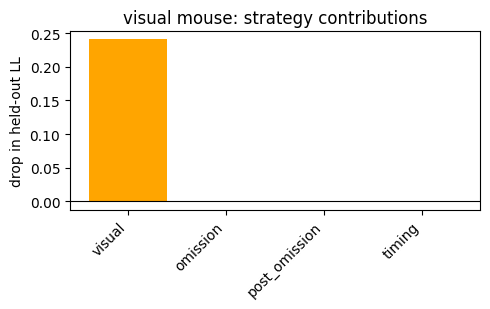

  visual         +0.2407
  omission       -0.0002
  post_omission  -0.0004
  timing         -0.0004


In [4]:
deltas = ablation_deltas(X, y, cols)
names = list(deltas)
plt.figure(figsize=(5, 3.2))
plt.bar(names, [deltas[n] for n in names], color=[sb.WEIGHT_COLORS[n] for n in names])
plt.ylabel("drop in held-out LL"); plt.title("visual mouse: strategy contributions")
plt.xticks(rotation=45, ha="right"); plt.axhline(0, color="k", lw=0.8)
plt.tight_layout(); plt.show()
for n in names:
    print(f"  {n:14s} {deltas[n]:+.4f}")

Exactly what we'd hope: removing **visual** collapses the model's predictions,
while removing omission, post-omission, or timing barely registers. On a
single-strategy mouse the ablation points, unambiguously, at the one strategy we
built in — the clean result that makes this the right place to trust the method.

### Across the population (Figure 2D)

One mouse gives one clean answer; the paper's Figure 2D shows the whole
**distribution** across the dataset. Let's reproduce its shape over a population
spanning the strategy spectrum (a coarser 3-fold CV keeps it quick, but the fits
still take **~10 s** — that's normal). To match the
paper we plot the **change** in the model's held-out score when a strategy is removed
(each dot a mouse, the black bar the population mean).

> ⚠️ **Sign flip.** These are the *same numbers as the bar chart above, negated.* The
> bar showed the **drop** (positive = important); here we show the **change when
> removed** (negative = important), to match the paper. A big drop up there is a big
> dip down here.

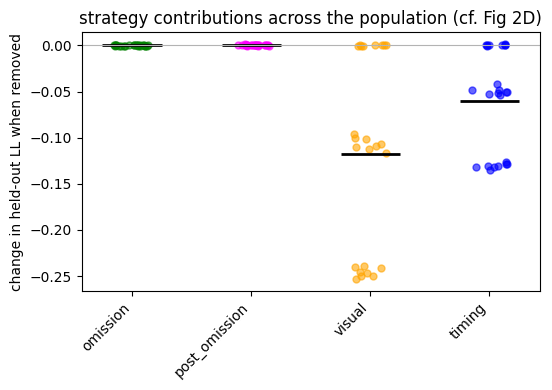

In [5]:
population = [sb.make_mouse(name, seed=s)
              for s in range(8) for name in ["visual", "timing", "mixed"]]
order = ["omission", "post_omission", "visual", "timing"]
dist = {s: [] for s in order}
for sess in population:
    X, y, cols = get_Xy(sess)
    d = sb.ablation_loglik_deltas(X, y, cols, n_folds=3)
    for s in order:
        dist[s].append(d[s])

plt.figure(figsize=(5.6, 4))
jit = np.random.default_rng(0)
for i, s in enumerate(order):
    change = -np.array(dist[s])        # change when removed = -(drop): negative if the strategy helps
    plt.scatter(i + jit.uniform(-0.15, 0.15, len(change)), change, s=25, alpha=0.6,
                color=sb.WEIGHT_COLORS[s])
    plt.hlines(change.mean(), i - 0.25, i + 0.25, color="k", lw=2)
plt.axhline(0, color="0.7", lw=0.8)
plt.xticks(range(len(order)), order, rotation=45, ha="right")
plt.ylabel("change in held-out LL when removed")
plt.title("strategy contributions across the population (cf. Fig 2D)")
plt.tight_layout(); plt.show()

Visual and timing plunge well below zero, with a wide spread — deep because mice rely
on them, spread because *which* of the two dominates depends on the individual mouse
(a timing mouse's visual change is near zero, and vice versa). Omission and
post-omission stay at zero. Removing a strategy the mouse actually uses makes the
model worse — exactly the negative excursions of Figure 2D.

## 3. The strategy index

Piet et al. summarize each session with two numbers — how much the model leans on
the **visual** vs the **timing** strategy — and their difference, the
**strategy index**:

$$\text{strategy index} = \Delta_{\text{visual}} - \Delta_{\text{timing}}.$$

Positive = visual-dominant, negative = timing-dominant. Let's compute it across a
population of single-strategy mice and reproduce the layout of Figure 2F.

In [6]:
def strategy_index(sess, n_folds=5):
    X, y, cols = get_Xy(sess)
    d = ablation_deltas(X, y, cols, n_folds)
    return d["visual"], d["timing"], d["visual"] - d["timing"]

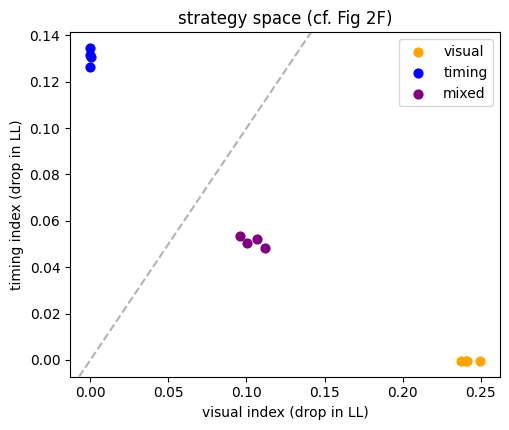

In [7]:
plt.figure(figsize=(5.2, 4.4))
colors = {"visual": sb.WEIGHT_COLORS["visual"], "timing": sb.WEIGHT_COLORS["timing"], "mixed": "purple"}
for name in ["visual", "timing", "mixed"]:
    for seed in range(4):
        vi, ti, si = strategy_index(sb.make_mouse(name, seed=seed))
        plt.scatter(vi, ti, color=colors[name], s=40,
                    label=name if seed == 0 else None)
plt.xlabel("visual index (drop in LL)"); plt.ylabel("timing index (drop in LL)")
plt.title("strategy space (cf. Fig 2F)"); plt.legend()
plt.axline((0, 0), slope=1, color="0.7", ls="--")
plt.tight_layout(); plt.show()

Visual mice sit in the bottom-right (high visual index, low timing), timing mice
in the top-left, and mixed mice near the diagonal — each strategy lands where it
should. In Notebook 6 we'll push this on mice that genuinely blend strategies.

---
## 4. (Advanced, optional) Model evidence

*Everything below is optional. If you're short on time, skip straight to §4.3 for
the result — the ablation verdict comes out the same as above.*

Ablation by held-out log-likelihood is intuitive and reuses the cross-validation
you already know. The paper instead compares models by their **evidence**, also
called the **marginal likelihood**: the probability the model assigns to the data
once the weights have been **averaged over**, rather than fixed at a single best
value,

$$p(y \mid \text{model}) = \int p(y \mid w)\, p(w)\, dw.$$

Here $p(w)$ is the prior over the weights, and the integral sweeps over *every*
possible weight vector, weighting each by how well it explains the data. Averaging
instead of fitting one best $w$ builds in an automatic penalty for spare
parameters: a model with an extra strategy must spread its prior over a
larger weight-space, so unless that strategy genuinely helps, the *average*
probability of the data goes **down**. That is a built-in Occam's razor, and it
needs no separate cross-validation.

### 4.1 What the Laplace approximation is *(optional deep-dive)*

That integral has no closed form for logistic regression, so we approximate it.
The **Laplace approximation** is a general trick for integrals of the form
$\int e^{g(w)}\,dw$ whose integrand has a single sharp peak: nearly all the area
sits under the peak, so we replace $g$ by its second-order Taylor expansion there,
which turns $e^{g}$ into a plain **Gaussian bump** we can integrate exactly.

In one dimension: let $w^{*}$ be the location of the peak, where $g'(w^{*}) = 0$.
Expanding to second order (the first-order term vanishes at the peak),

$$g(w) \approx g(w^{*}) - \tfrac{1}{2}\,|g''(w^{*})|\,(w - w^{*})^2,$$

so $e^{g(w)}$ is approximately $e^{g(w^{*})}$ times a Gaussian in $w$. Using the
standard Gaussian integral $\int e^{-\frac12 a (w-\mu)^2}\,dw = \sqrt{2\pi/a}$,

$$\int e^{g(w)}\,dw \;\approx\; e^{g(w^{*})}\,\sqrt{\frac{2\pi}{|g''(w^{*})|}}
\;=\; \underbrace{e^{g(w^{*})}}_{\text{peak height}} \times \underbrace{\sqrt{2\pi/|g''(w^{*})|}}_{\text{peak width}}.$$

The width comes from the **curvature** $|g''(w^{*})|$: a sharper peak (large
curvature) is narrower and encloses less area. In many dimensions the same formula
holds with $|g''|$ replaced by the determinant of the **Hessian** (the matrix of
second derivatives) — which is exactly what `sb.log_evidence_laplace` computes.

### 4.2 Try it on a coin *(optional exercise)*

Let's watch the approximation work on a case we *can* solve exactly. Flip a coin
$n$ times, observe $k$ heads, and put a flat prior on the head-probability $p$. The
evidence is

$$\int_0^1 p^{\,k}(1-p)^{\,n-k}\,dp \;=\; \frac{k!\,(n-k)!}{(n+1)!}$$

(a standard Beta integral — the exact value is on the right). Now approximate the
*same* integral with Laplace, taking $g(p) = k\log p + (n-k)\log(1-p)$, whose peak
sits at $p^{*} = k/n$.

**Exercise (optional)** *(~5 min)*. Fill in the Laplace estimate: the curvature is
$|g''(p^{*})| = k/p^{*2} + (n-k)/(1-p^{*})^2$, and the estimate is
$e^{g(p^{*})}\sqrt{2\pi/|g''(p^{*})|}$.

> **Check / unstuck.** The Laplace/exact **ratio should approach 1** as $n$ grows
> (≈ 1.07, 1.01, 1.00). Fully optional — skip to §4.3 if short on time.

In [8]:
from math import factorial, log, sqrt, pi, exp

def coin_evidence_exact(k, n):
    return factorial(k) * factorial(n - k) / factorial(n + 1)

def coin_evidence_laplace(k, n):
    p = k / n                                       # peak of g
    g_peak = k * log(p) + (n - k) * log(1 - p)      # log integrand at the peak
    curv = k / p**2 + (n - k) / (1 - p)**2          # |g''(p*)|
    return exp(g_peak) * sqrt(2 * pi / curv)

for k, n in [(3, 10), (30, 100), (300, 1000)]:
    exact, approx = coin_evidence_exact(k, n), coin_evidence_laplace(k, n)
    print(f"k={k:4d} n={n:5d}:  exact={exact:.3e}  laplace={approx:.3e}  ratio={approx/exact:.3f}")

k=   3 n=   10:  exact=7.576e-04  laplace=8.077e-04  ratio=1.066
k=  30 n=  100:  exact=3.371e-28  laplace=3.394e-28  ratio=1.007
k= 300 n= 1000:  exact=1.840e-267  laplace=1.842e-267  ratio=1.001


The ratio approaches $1$ as $n$ grows: more data makes the peak sharper and more
Gaussian, so Laplace gets better. That's the same regime our 4800-image sessions
live in.

### 4.3 Ablation by evidence

`sb.log_evidence_laplace` applies this exact idea to the logistic model — many
dimensions, so a Hessian determinant stands in for $|g''|$ — combining the fit at
the peak, the prior, and the peak width. Redo the ablation with it:

In [9]:
def evidence_deltas(X, y, cols, prior_var=100.0):
    full_ev = sb.log_evidence_laplace(X, y, prior_var)
    out = {}
    for k, name in enumerate(cols):
        if name == "bias":
            continue
        out[name] = full_ev - sb.log_evidence_laplace(np.delete(X, k, axis=1), y, prior_var)
    return out

ev = evidence_deltas(X, y, cols)
print("change in log-evidence when each strategy is removed:")
for n in names:
    print(f"  {n:14s} evidence {ev[n]:+9.1f}   held-out-LL {deltas[n]:+.4f}")

change in log-evidence when each strategy is removed:
  visual         evidence    +556.8   held-out-LL +0.2407
  omission       evidence      -3.4   held-out-LL -0.0002
  post_omission  evidence      -3.5   held-out-LL -0.0004
  timing         evidence    +242.0   held-out-LL -0.0004


Both methods crown **visual** by a wide margin and rank the rest near zero. The
evidence differences are large in absolute terms (they sum log-probabilities over
all 4800 images rather than averaging), which is why the paper reports them as a
**percent change in evidence** (Fig 2D). The takeaway is the same: on these mice,
one strategy carries the model.

## Wrap-up

You measured what each strategy contributes by ablation, and distilled it into
the strategy index that organizes the paper's Figure 2 — verified on mice whose
answer we already knew.

**Next (Notebook 6):** stress-test the whole fit → evaluate → ablate cycle on
mice that truly mix strategies, where the index has to earn its keep.